### Machine learning Assignment

Q1.) Create a NumPy array of 50 random numbers and find the 2nd largest and 3rd smallest element.

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
arr = np.random.randint(1,100,50)

In [68]:
arr.sort()

In [69]:
second_largest  = arr[-2]
third_largest = arr[-3]
print("Second largest no. : ",second_largest)
print("Third largest : ",third_largest)

Second largest no. :  97
Third largest :  97


Q2.) Given a DataFrame, identify all columns having more than 20% missing values and remove them. 

In [70]:
df = pd.DataFrame({
    'A': [1, 2, None, 4, 5],
    'B': [None, None, 3, None, 5],
    'C': [10, 20, 30, 40, 50],
    'D': [None, None, None, 4, 5]
})
missing_percent = df.isnull().mean() * 100
null_col = missing_percent[missing_percent > 20].index
df_cleaned = df.drop(null_col,axis=1)
print("Cleaned DataFrame:")
print(df_cleaned)

Cleaned DataFrame:
     A   C
0  1.0  10
1  2.0  20
2  NaN  30
3  4.0  40
4  5.0  50


Q3.) Create a NumPy matrix and find its transpose, determinant, rank, and inverse.  

In [71]:
matrix = np.array([[1, 2, 3],
                   [0, 1, 4],
                   [5, 6, 0]])

print("Original Matrix:")
print(matrix)

Original Matrix:
[[1 2 3]
 [0 1 4]
 [5 6 0]]


In [72]:
transpose = matrix.T
print("1. Transpose of the Matrix:")
print(transpose)
determinant = np.linalg.det(matrix)
print(f"2. Determinant: {round(determinant, 2)}")
rank = np.linalg.matrix_rank(matrix)
print(f"3. Rank of the Matrix: {rank}")
if not np.isclose(determinant, 0):
    inverse = np.linalg.inv(matrix)
    print("4. Inverse of the Matrix:")
    print(inverse)
else:
    print("4. Inverse: Cannot be computed because the matrix is singular (determinant is 0).")

1. Transpose of the Matrix:
[[1 0 5]
 [2 1 6]
 [3 4 0]]
2. Determinant: 1.0
3. Rank of the Matrix: 3
4. Inverse of the Matrix:
[[-24.  18.   5.]
 [ 20. -15.  -4.]
 [ -5.   4.   1.]]


Q4.) Using Pandas, find the top 5 categories with the highest average value of a numerical column.  

In [73]:
data = {
    "Category": [
        "Electronics", "Clothing", "Electronics", "Home", "Books",
        "Clothing", "Home", "Books", "Electronics", "Groceries",
        "Groceries", "Toys", "Toys", "Automotive", "Automotive"
    ],
    "Sales_Value": [
        1200, 150, 800, 300, 50,
        200, 450, 40, 1500, 90,
        110, 250, 150, 3000, 1500
    ]
}

df = pd.DataFrame(data)
top_5_categories = df.groupby("Category")["Sales_Value"].mean().nlargest(5)
print("Original DataFrame Snippet:")
print(df.head(6))
print(" \nTop 5 Categories with Highest Average Value:")
print(top_5_categories)

Original DataFrame Snippet:
      Category  Sales_Value
0  Electronics         1200
1     Clothing          150
2  Electronics          800
3         Home          300
4        Books           50
5     Clothing          200
 
Top 5 Categories with Highest Average Value:
Category
Automotive     2250.000000
Electronics    1166.666667
Home            375.000000
Toys            200.000000
Clothing        175.000000
Name: Sales_Value, dtype: float64


Q5.) Create a Seaborn heatmap and identify the three most highly correlated feature pairs.  

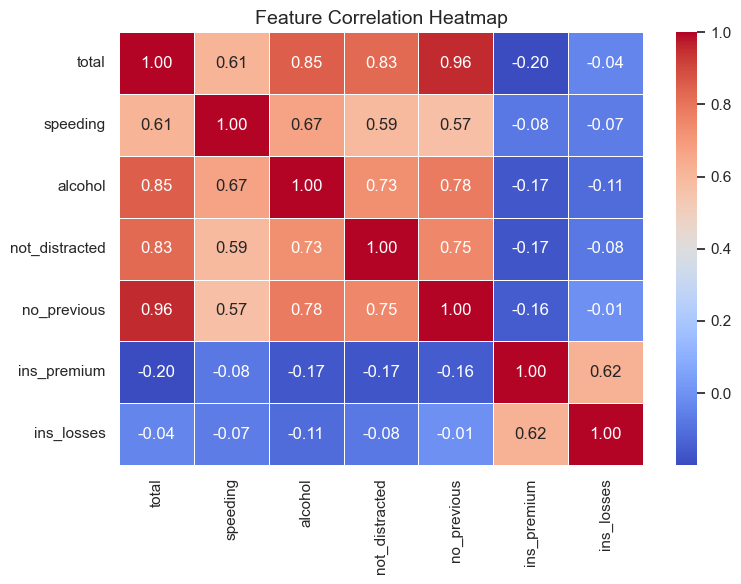

Top 3 Most Highly Correlated Feature Pairs:
1. total & no_previous 
   Correlation Coefficient: 0.9562

2. alcohol & total 
   Correlation Coefficient: 0.8526

3. not_distracted & total 
   Correlation Coefficient: 0.8276



In [74]:
df = sns.load_dataset("car_crashes")
numerical_df = df.select_dtypes(include=["float64", "int64"])
corr_matrix = numerical_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()
sol = corr_matrix.abs().unstack()
sorted_pairs = sol.sort_values(ascending=False)
distinct_pairs = sorted_pairs[sorted_pairs < 1.0].drop_duplicates()
print("Top 3 Most Highly Correlated Feature Pairs:")
for i, (pair, val) in enumerate(distinct_pairs.head(3).items(), 1):
    original_val = corr_matrix.loc[pair[0], pair[1]]
    print(f"{i}. {pair[0]} & {pair[1]} \n   Correlation Coefficient: {original_val:.4f}\n")

Q6.) Generate a dataset with NumPy and visualize its distribution using Histogram, KDE Plot, and Box Plot.  

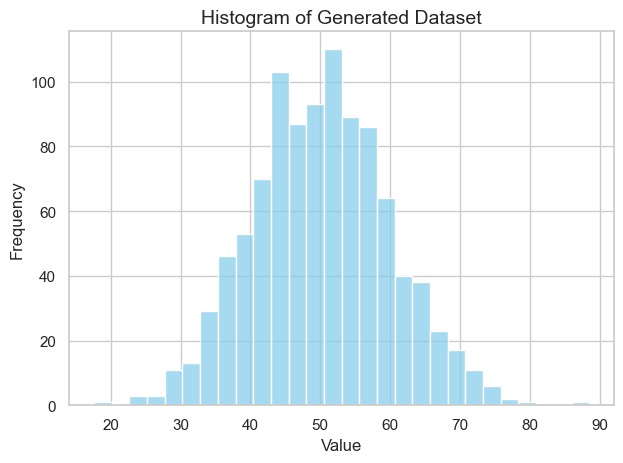

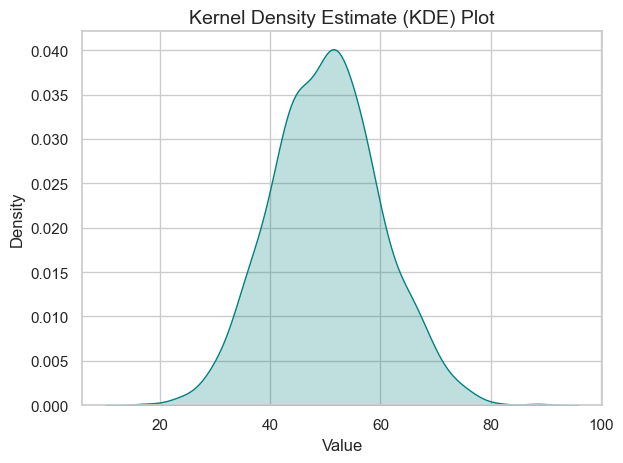

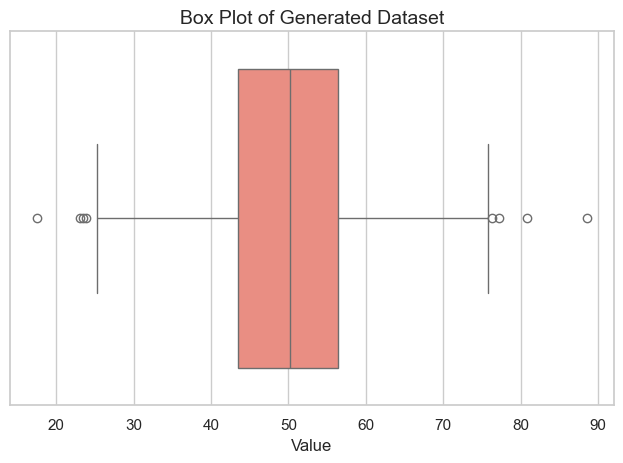

In [75]:
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=1000)
sns.set_theme(style="whitegrid")
sns.histplot(data, color="skyblue", kde=False)
plt.title("Histogram of Generated Dataset", fontsize=14)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
sns.kdeplot(data, color="teal", fill=True)
plt.title("Kernel Density Estimate (KDE) Plot", fontsize=14)
plt.xlabel("Value")
plt.ylabel("Density")
plt.tight_layout()
plt.show()
sns.boxplot(x=data, color="salmon")
plt.title("Box Plot of Generated Dataset", fontsize=14)
plt.xlabel("Value")
plt.tight_layout()
plt.show()


Q7.) Using Pandas GroupBy, find the highest, lowest, and average sales for each category.  

In [76]:
data = {
    "Category": [
        "Electronics",
        "Clothing",
        "Electronics",
        "Home",
        "Home",
        "Clothing",
        "Electronics",
        "Home",
    ],
    "Sales": [1200, 150, 850, 400, 300, 250, 1600, 450],
}

df = pd.DataFrame(data)
sales_summary = df.groupby("Category")["Sales"].agg(["max", "min", "mean"])
sales_summary.columns = ["Highest_Sales", "Lowest_Sales", "Average_Sales"]
print("Original DataFrame:")
print(df)
print("Sales Summary by Category:")
print(sales_summary)

Original DataFrame:
      Category  Sales
0  Electronics   1200
1     Clothing    150
2  Electronics    850
3         Home    400
4         Home    300
5     Clothing    250
6  Electronics   1600
7         Home    450
Sales Summary by Category:
             Highest_Sales  Lowest_Sales  Average_Sales
Category                                               
Clothing               250           150     200.000000
Electronics           1600           850    1216.666667
Home                   450           300     383.333333


Q8.) Detect outliers in a numerical column using the IQR method and 
visualize them using a Box Plot. 

Lower Bound: 27.17321545886533
Upper Bound: 71.70971029326903
Outliers:
 [ 23.80254896 100.         105.          -5.         -10.        ]


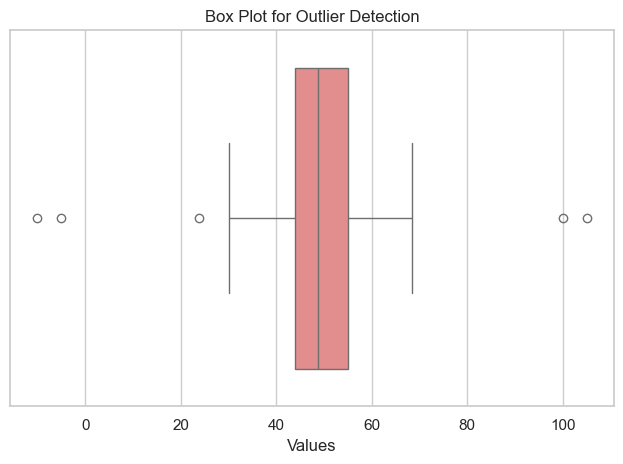

In [77]:
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)
data = np.append(data, [100, 105, -5, -10])

df = pd.DataFrame(data, columns=["Values"])

q1 = df["Values"].quantile(0.25)
q3 = df["Values"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df["Values"] < lower_bound) | (df["Values"] > upper_bound)]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Outliers:\n", outliers["Values"].values)

sns.boxplot(x=df["Values"], color="lightcoral")
plt.title("Box Plot for Outlier Detection")
plt.xlabel("Values")
plt.tight_layout()
plt.show()

Q9.) Create a Matplotlib figure containing 4 subplots:  
o Line Plot  
o Bar Plot  
o Scatter Plot  
o Histogram 

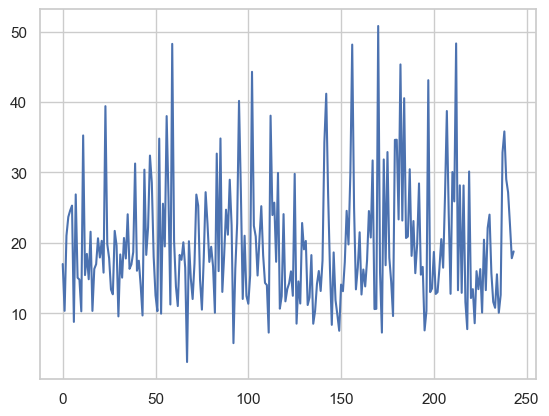

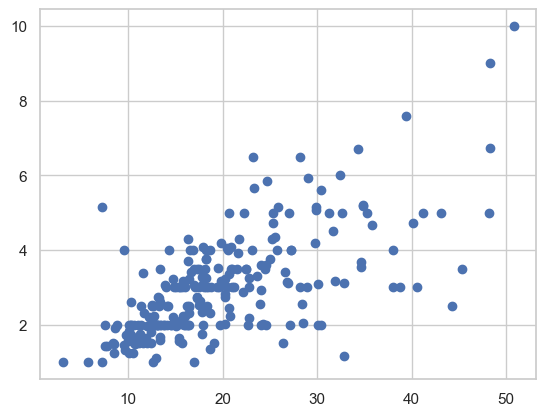

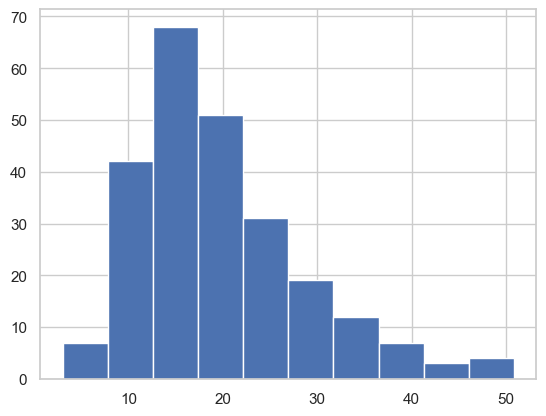

In [78]:
data  = sns.load_dataset('tips')
plt.plot(data['total_bill'])
plt.show()
plt.scatter(data['total_bill'],data['tip'])
plt.show()
plt.hist(data['total_bill'])
plt.show()


Q10.) Create a rolling average of window size 7 on a dataset and compare 
it with the original trend using Matplotlib.  

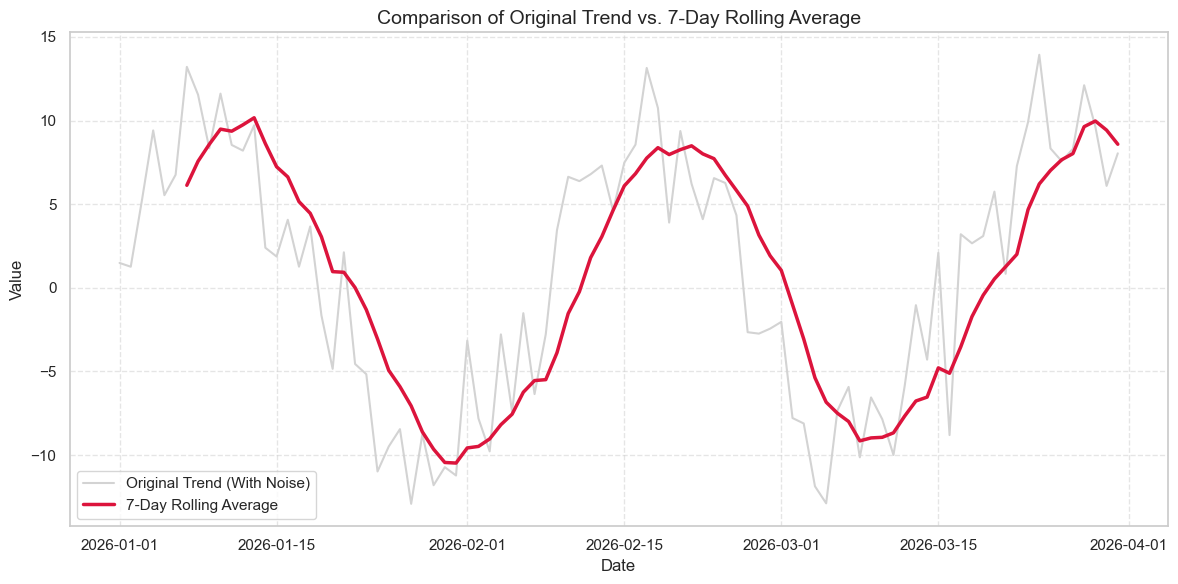

In [79]:
np.random.seed(42)
dates = pd.date_range(start="2026-01-01", periods=90)
signal = np.sin(np.linspace(0, 15, 90)) * 10
noise = np.random.normal(0, 3, 90)
values = signal + noise

df = pd.DataFrame({"Value": values}, index=dates)

df["Rolling_Avg"] = df["Value"].rolling(window=7).mean()

plt.figure(figsize=(12, 6))
plt.plot(
    df.index,
    df["Value"],
    label="Original Trend (With Noise)",
    color="lightgray",
    linewidth=1.5,
)
plt.plot(
    df.index,
    df["Rolling_Avg"],
    label="7-Day Rolling Average",
    color="crimson",
    linewidth=2.5,
)

plt.title("Comparison of Original Trend vs. 7-Day Rolling Average", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Q11.)Using Seaborn, compare two numerical features using:  
● Scatter Plot  
● Pair Plot  
● Joint Plot  

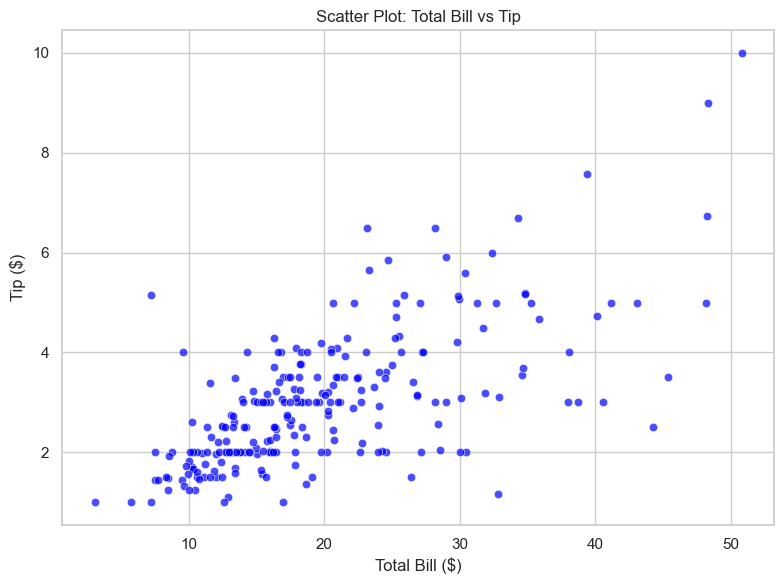

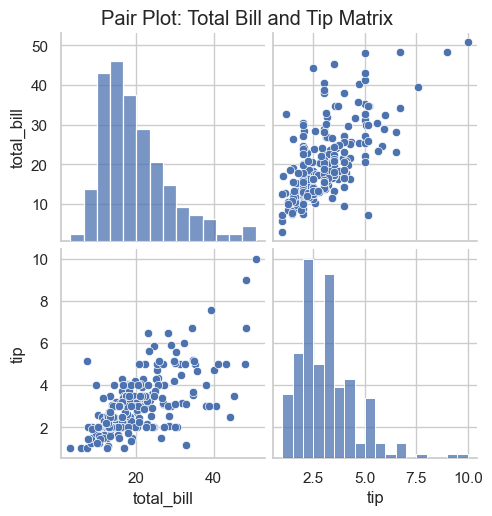

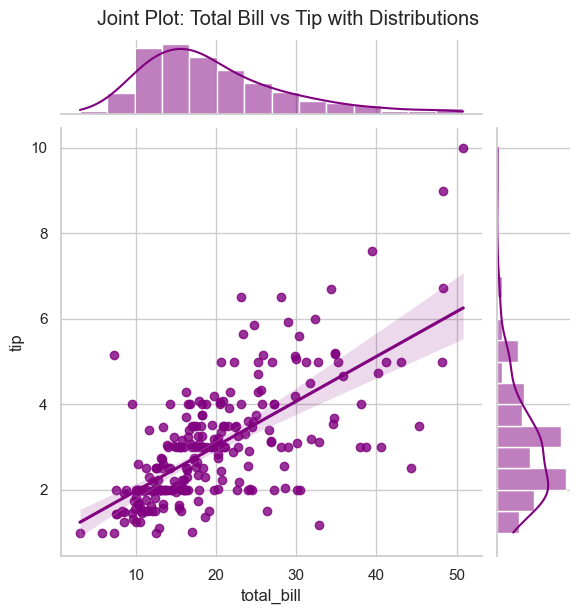

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
tips = sns.load_dataset("tips")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tips, x="total_bill", y="tip", color="blue", alpha=0.7)
plt.title("Scatter Plot: Total Bill vs Tip")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.tight_layout()
plt.show()

sns.pairplot(data=tips[["total_bill", "tip"]])
plt.suptitle("Pair Plot: Total Bill and Tip Matrix", y=1.02)
plt.show()

joint_plt = sns.jointplot(
    data=tips, x="total_bill", y="tip", kind="reg", color="purple"
)
joint_plt.fig.suptitle("Joint Plot: Total Bill vs Tip with Distributions", y=1.02)
plt.show()

Q12.) Build a mini EDA report that includes:  
● Missing Values Analysis  
● Correlation Analysis  
● Outlier Detection  
● Feature Distribution Visualization

             MINI EDA REPORT              

[1] MISSING VALUES ANALYSIS
                   Missing Count  Percentage (%)
bill_length_mm                 2        0.581395
bill_depth_mm                  2        0.581395
flipper_length_mm              2        0.581395
body_mass_g                    2        0.581395
sex                           11        3.197674

[2] OUTLIER DETECTION (IQR METHOD)
Feature: bill_length_mm
  Lower Bound: 25.44 | Upper Bound: 62.34
  Number of Outliers: 0

Feature: bill_depth_mm
  Lower Bound: 10.95 | Upper Bound: 23.35
  Number of Outliers: 0

Feature: flipper_length_mm
  Lower Bound: 155.50 | Upper Bound: 247.50
  Number of Outliers: 0

Feature: body_mass_g
  Lower Bound: 1750.00 | Upper Bound: 6550.00
  Number of Outliers: 0

[3] CORRELATION ANALYSIS
Correlation Matrix:
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm              1.000         -0.235              0.656   
bill_depth_mm              -0.235         

C:\Users\user\AppData\Local\Temp\ipykernel_26444\2979265533.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y="body_mass_g", ax=axs[0, 1], palette="pastel")


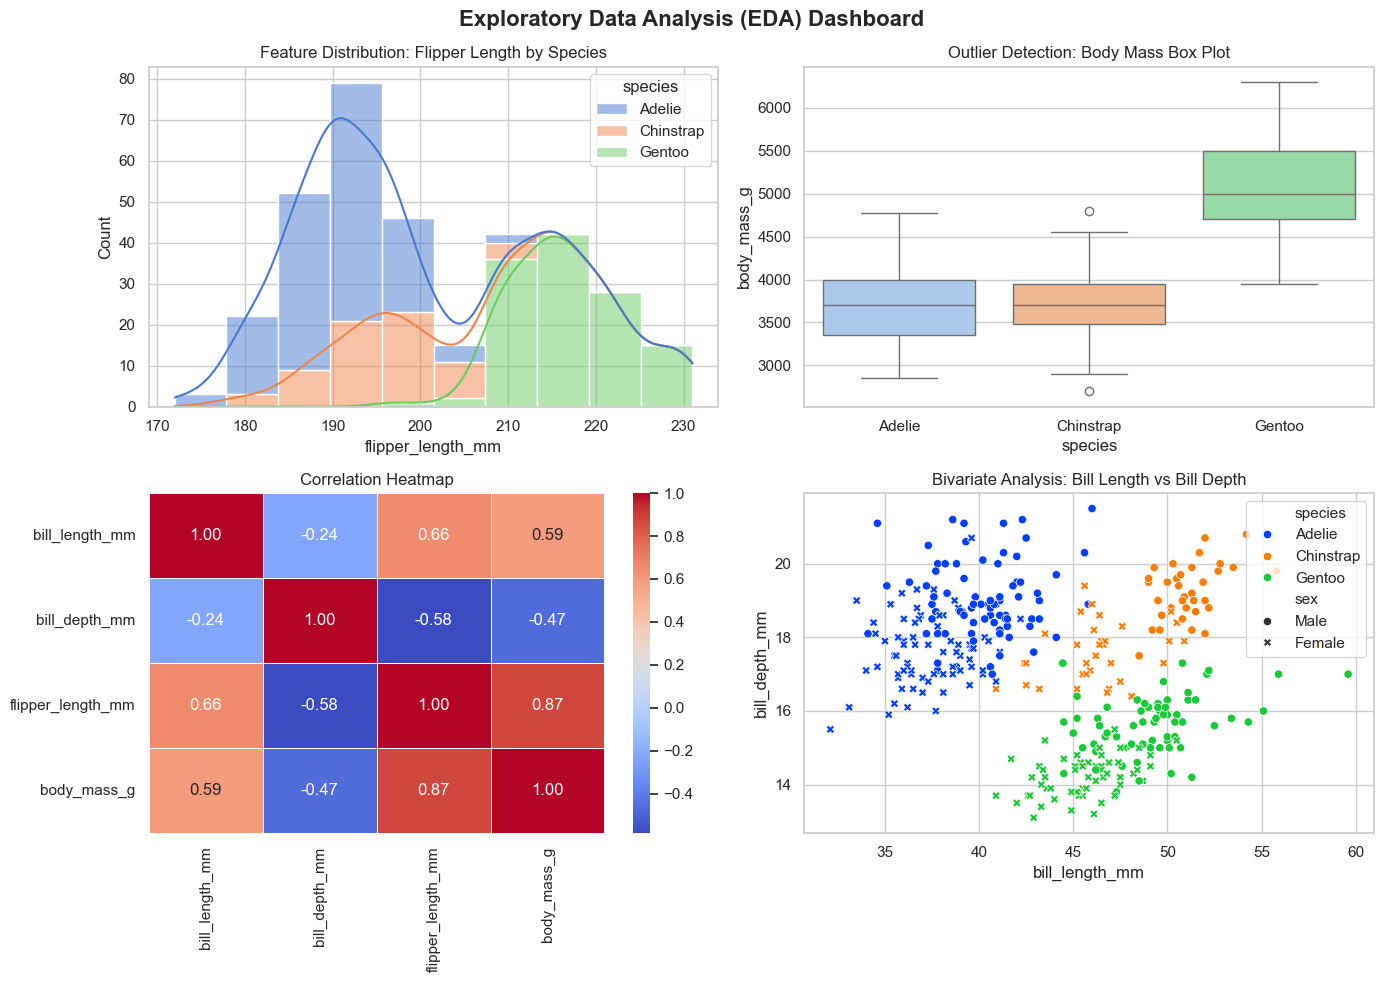

In [81]:
df = sns.load_dataset("penguins")
print("             MINI EDA REPORT              ")
print("\n[1] MISSING VALUES ANALYSIS")
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame(
    {"Missing Count": missing_counts, "Percentage (%)": missing_percentages}
)
print(missing_df[missing_df["Missing Count"] > 0])

numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())
df["sex"] = df["sex"].fillna(df["sex"].mode()[0])

print("\n[2] OUTLIER DETECTION (IQR METHOD)")
for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Feature: {col}")
    print(f"  Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}")
    print(f"  Number of Outliers: {len(outliers)}\n")

print("[3] CORRELATION ANALYSIS")
corr_matrix = df[numerical_cols].corr()
print("Correlation Matrix:")
print(corr_matrix.round(3))

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(
    data=df,
    x="flipper_length_mm",
    hue="species",
    kde=True,
    multiple="stack",
    ax=axs[0, 0],
    palette="muted",
)
axs[0, 0].set_title("Feature Distribution: Flipper Length by Species")

sns.boxplot(data=df, x="species", y="body_mass_g", ax=axs[0, 1], palette="pastel")
axs[0, 1].set_title("Outlier Detection: Body Mass Box Plot")

sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=axs[1, 0]
)
axs[1, 0].set_title("Correlation Heatmap")

sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    style="sex",
    ax=axs[1, 1],
    palette="bright",
)
axs[1, 1].set_title("Bivariate Analysis: Bill Length vs Bill Depth")

plt.suptitle("Exploratory Data Analysis (EDA) Dashboard", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()